# bgc-infiller EDA - Análisis exploratorio de datos

In [1]:
%cd ..

a:\IA\TFM\bgc-infiller


C:\Users\lmjim\AppData\Roaming\Python\Python310\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from src import utils
df = utils.read_bgcs_from_csv('./data/formatted_bgc_data.csv')

df['gene_count'] = df['gene_names'].apply(len)
df['gene_lengths'] = df['gene_sequences'].apply(lambda seqs: [len(seq) for seq in seqs])
df.info()
df.describe()
df.shape
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2636 entries, 0 to 2635
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   BGC             2636 non-null   object
 1   class           2636 non-null   object
 2   organism        2636 non-null   object
 3   compounds       2636 non-null   object
 4   gene_names      2636 non-null   object
 5   gene_sequences  2636 non-null   object
 6   gene_count      2636 non-null   int64 
 7   gene_lengths    2636 non-null   object
dtypes: int64(1), object(7)
memory usage: 164.9+ KB


,BGC,class,organism,compounds,gene_names,gene_sequences,gene_count,gene_lengths
0,BGC0000001,PKS,Micromonospora maris AB-18-032,"[abyssomicin C, atrop-abyssomicin C]","[abyB1, abyB2, abyB3]",[MSAPDEPVAVVGLACRLPGAADPEAFWALLRDGREAITDPPASRR...,3,"[5781, 3645, 992]"
1,BGC0000002,PKS,Kutzneria albida DSM 43870,[aculeximycin],"[acuAVIII, acuAVII, acuAVI, acuAV, acuAIV, acu...",[MANQDKLLDYLKRVTADLHQTRQRLREVEAGEPEPIAIVAMSCRF...,15,"[3713, 2967, 7833, 4408, 3214, 1754, 4994, 552..."
2,BGC0000003,PKS,Alternaria alternata,[AF-toxin],[AFT9-1],[MDPQQRLLLETTYEALENAGIPQANTNGSNTSVHVAMFTRDYDRN...,1,[3005]
3,BGC0000004,PKS,Aspergillus oryzae,[aflatoxin G1],[pksA],[MAQSRQLFLFGDQTADFVPKLRSLLSVQDSPILAAFLDQSHYVVR...,1,[2009]
4,BGC0000006,PKS,Aspergillus flavus,"[aflatoxin B1, aflatoxin B2]",[pksA],[MAQSRQLFLFGDQTADFVPKLRSLLSVQDSPILAAFLDQSHYVVR...,1,[2109]


Frecuencia por clase:
NRPS: 875
PKS: 738
other: 354
ribosomal: 358
saccharide: 140
terpene: 171

Proporción por clase:
NRPS: 33.19%
PKS: 28.00%
other: 13.43%
ribosomal: 13.58%
saccharide: 5.31%
terpene: 6.49%


C:\Users\lmjim\AppData\Local\Temp\ipykernel_27528\4018470988.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


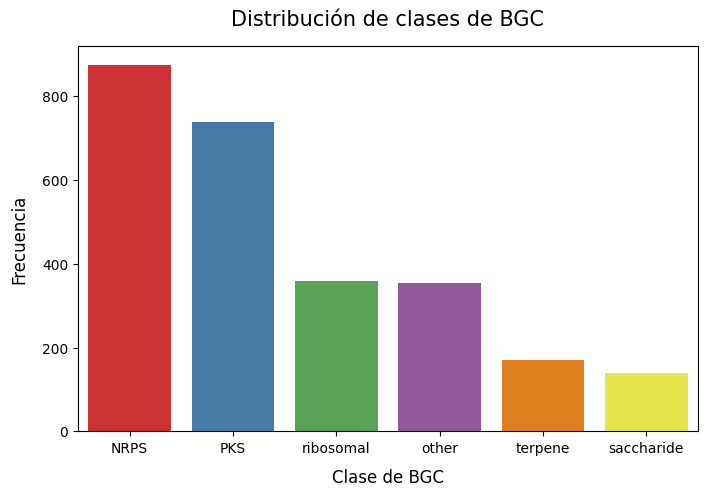

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = {
  0: 'NRPS',
  1: 'PKS',
  2: 'other',
  3: 'ribosomal',
  4: 'saccharide',
  5: 'terpene'
}

sorted_values = df['class'].value_counts().index

plt.figure(figsize=(8, 5))
sns.countplot(
    x='class',
    data=df,
    order=sorted_values,
    palette='Set1'
)

plt.title('Distribución de clases de BGC', fontsize=15, pad=15)
plt.xlabel('Clase de BGC', fontsize=12, labelpad=10)
plt.ylabel('Frecuencia', fontsize=12, labelpad=10)

counts = df['class'].value_counts().sort_index()
print("Frecuencia por clase:")
for cls, count in counts.items():
  print(f"{cls}: {count}")
print("\nProporción por clase:")
for cls, count in counts.items():
  print(f"{cls}: {count/df.shape[0] * 100:.2f}%")

plt.show()

count    2636.000000
mean        2.591426
std         2.501989
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        41.000000
Name: gene_count, dtype: float64


C:\Users\lmjim\AppData\Local\Temp\ipykernel_24488\3616751443.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


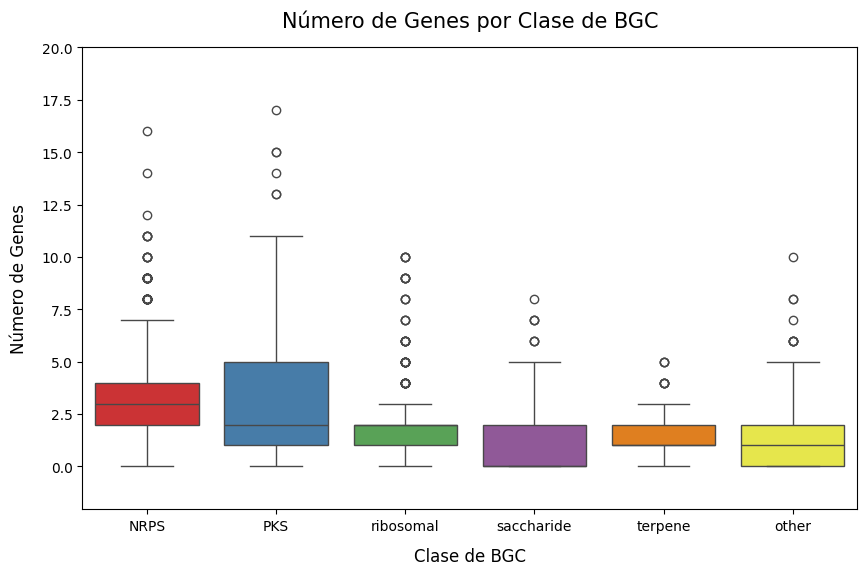

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x='class', 
    y='gene_count', 
    order=class_names.values(),
    palette='Set1'
)

plt.title('Número de Genes por Clase de BGC', fontsize=15, pad=15)
plt.xlabel('Clase de BGC', fontsize=12, labelpad=10)
plt.ylabel('Número de Genes', fontsize=12, labelpad=10)
plt.ylim(top=20)

print(df['gene_count'].describe())
plt.show()

count     6831.000000
mean      2098.707217
std       2104.449681
min         28.000000
25%        425.000000
50%       1506.000000
75%       3065.000000
max      18447.000000
Name: gene_lengths, dtype: float64


C:\Users\lmjim\AppData\Local\Temp\ipykernel_24488\757928589.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


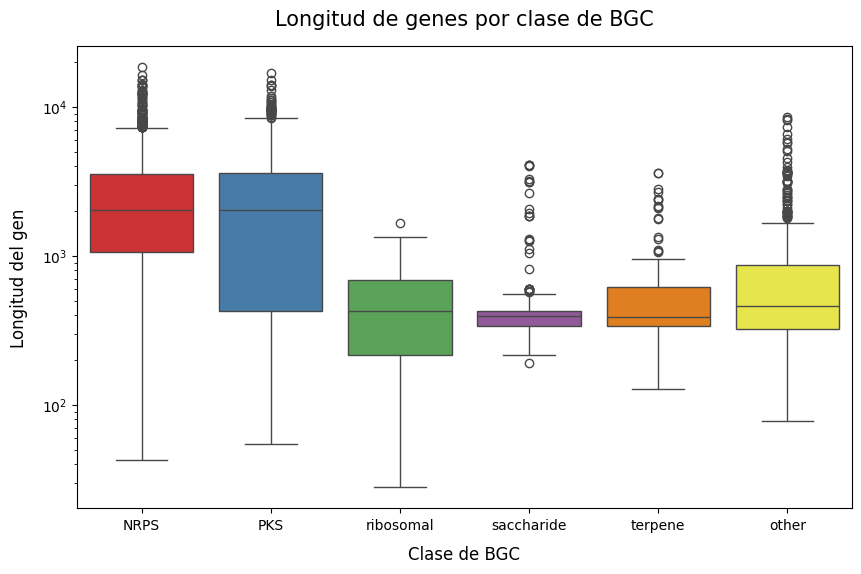

In [99]:
import ast

df_exploded = df.copy()
df_exploded['gene_lengths'] = df_exploded['gene_lengths'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_exploded = df_exploded.explode('gene_lengths').reset_index(drop=True)
df_exploded['gene_lengths'] = df_exploded['gene_lengths'].astype(float)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_exploded,
    x='class',
    y='gene_lengths',
    order=class_names.values(),
    palette='Set1'
)

plt.title('Longitud de genes por clase de BGC', fontsize=15, pad=15)
plt.xlabel('Clase de BGC', fontsize=12, labelpad=10)
plt.ylabel('Longitud del gen', fontsize=12, labelpad=10)
plt.yscale('log')

print(df_exploded['gene_lengths'].describe())
plt.show()